# Exploratory Data Analysis

· Previously, we examined the various tables in the database to identify key variables, understand their relationships, and determine which ones should be included in the final analysis. 

· In this phase of EDA, we will analyze the resultant table to gain insights into the distribution of each column. This will help us understand data patterns, identify anomalies, and ensure data quality before proceeding with further analysis.

In [1]:
import pandas as pd
import numpy as np 
import sqlite3
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns 


In [2]:
os.chdir('G:/Data Analytics Project/Vendor_Performance')

In [3]:
%pwd

'G:\\Data Analytics Project\\Vendor_Performance'

In [4]:
conn = sqlite3.connect(r'artifacts\InventoryDB\inventory_data.db')

In [5]:
query = """
    Select * from new_vendor_sales_summary
"""

df = pd.read_sql_query(query, conn)
df.head()

,VendorName,VendorNumber,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchasedQuantity,TotalPurchaseDollar,TotalSalesDollar,TotalSalesPrice,TotalSalesQuantity,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnOver,SalestoPruchaseRatio
0,BROWN-FORMAN CORP,1128,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,5101919.51,672819.31,142049.0,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,MARTIGNETTI COMPANIES,4425,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,4819073.49,561512.37,160247.0,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,PERNOD RICARD USA,17035,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,4538120.60,461140.15,187140.0,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,DIAGEO NORTH AMERICA INC,3960,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,4475972.88,420050.01,200412.0,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,DIAGEO NORTH AMERICA INC,3960,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,4223107.62,545778.28,135838.0,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


In [6]:
#  summary statistics
a = df.describe().T
a

g:\Data Analytics Project\Vendor_Performance\.venv\Lib\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,1.065065e+04,18753.519148,2.00,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,1.803923e+04,12662.187074,58.00,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,10692.0,2.438530e+01,109.269375,0.36,6.840000,10.455000,19.482500,5.681810e+03
ActualPrice,10692.0,3.564367e+01,148.246016,0.49,10.990000,15.990000,28.990000,7.499990e+03
Volume,10692.0,8.473605e+02,664.309212,50.00,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchasedQuantity,10692.0,3.140887e+03,11095.086769,1.00,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollar,10692.0,3.010669e+04,123067.799627,0.71,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesDollar,10692.0,4.223907e+04,167655.265984,0.00,729.220000,5298.045000,28396.915000,5.101920e+06
TotalSalesPrice,10692.0,1.879378e+04,44952.773386,0.00,289.710000,2857.800000,16059.562500,6.728193e+05
TotalSalesQuantity,10692.0,3.077482e+03,10952.851391,0.00,33.000000,261.000000,1929.250000,3.349390e+05


In [7]:
df[['ActualPrice', 'PurchasePrice']].max()

df[['ActualPrice', 'PurchasePrice']].min()

ActualPrice      0.49
PurchasePrice    0.36
dtype: float64

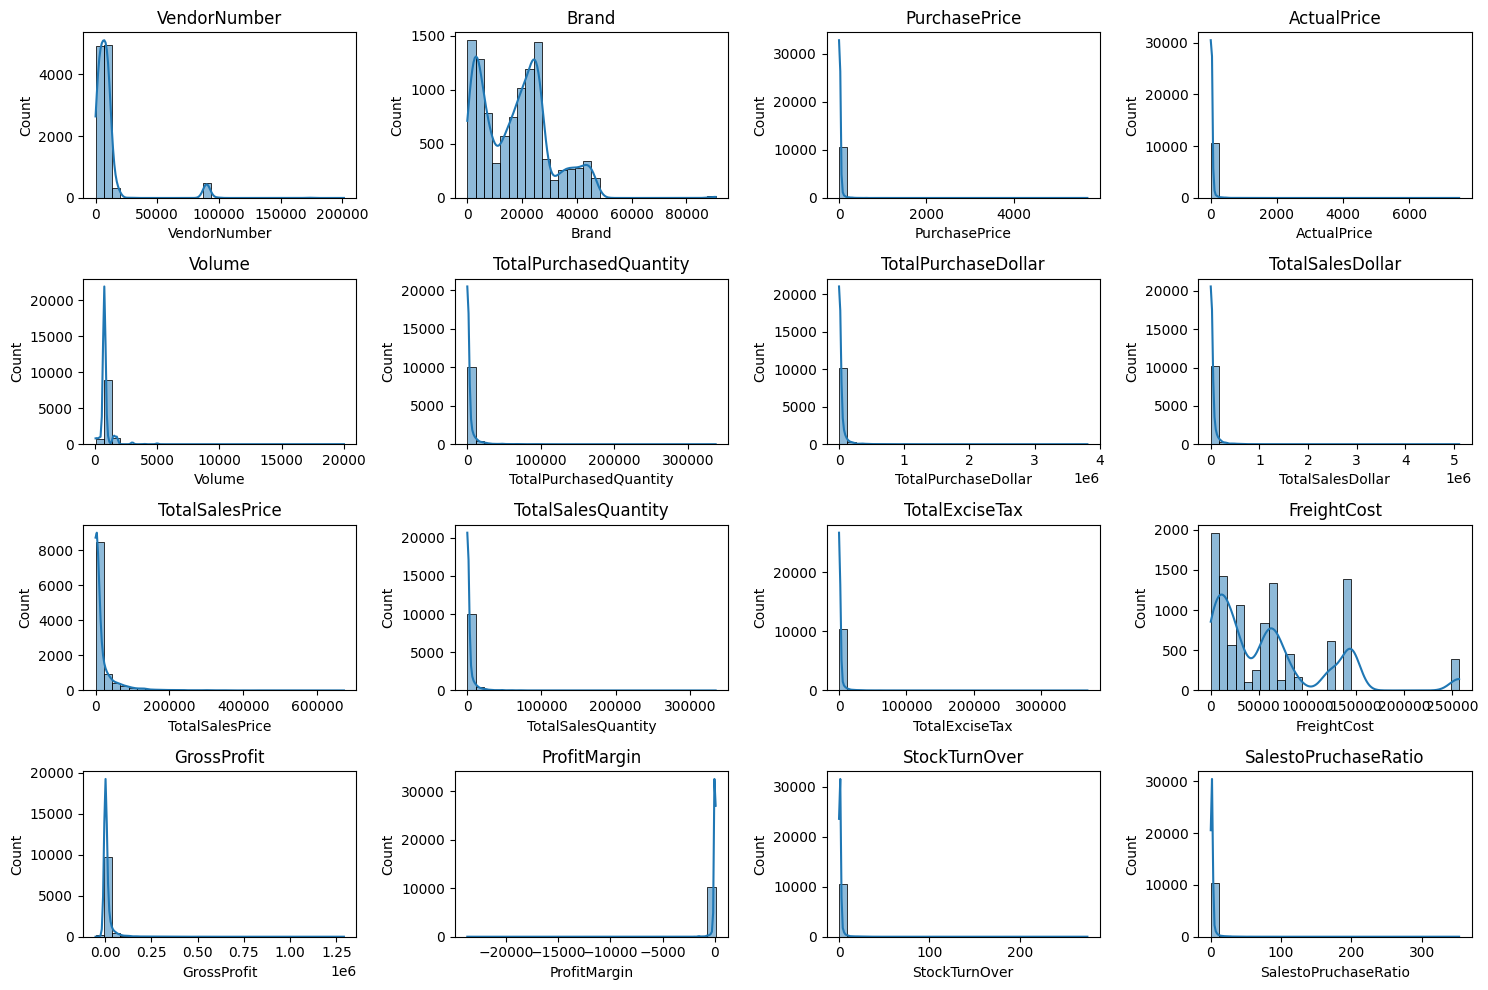

In [8]:
#  distribution plots for Numerical Colums

from re import L


numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

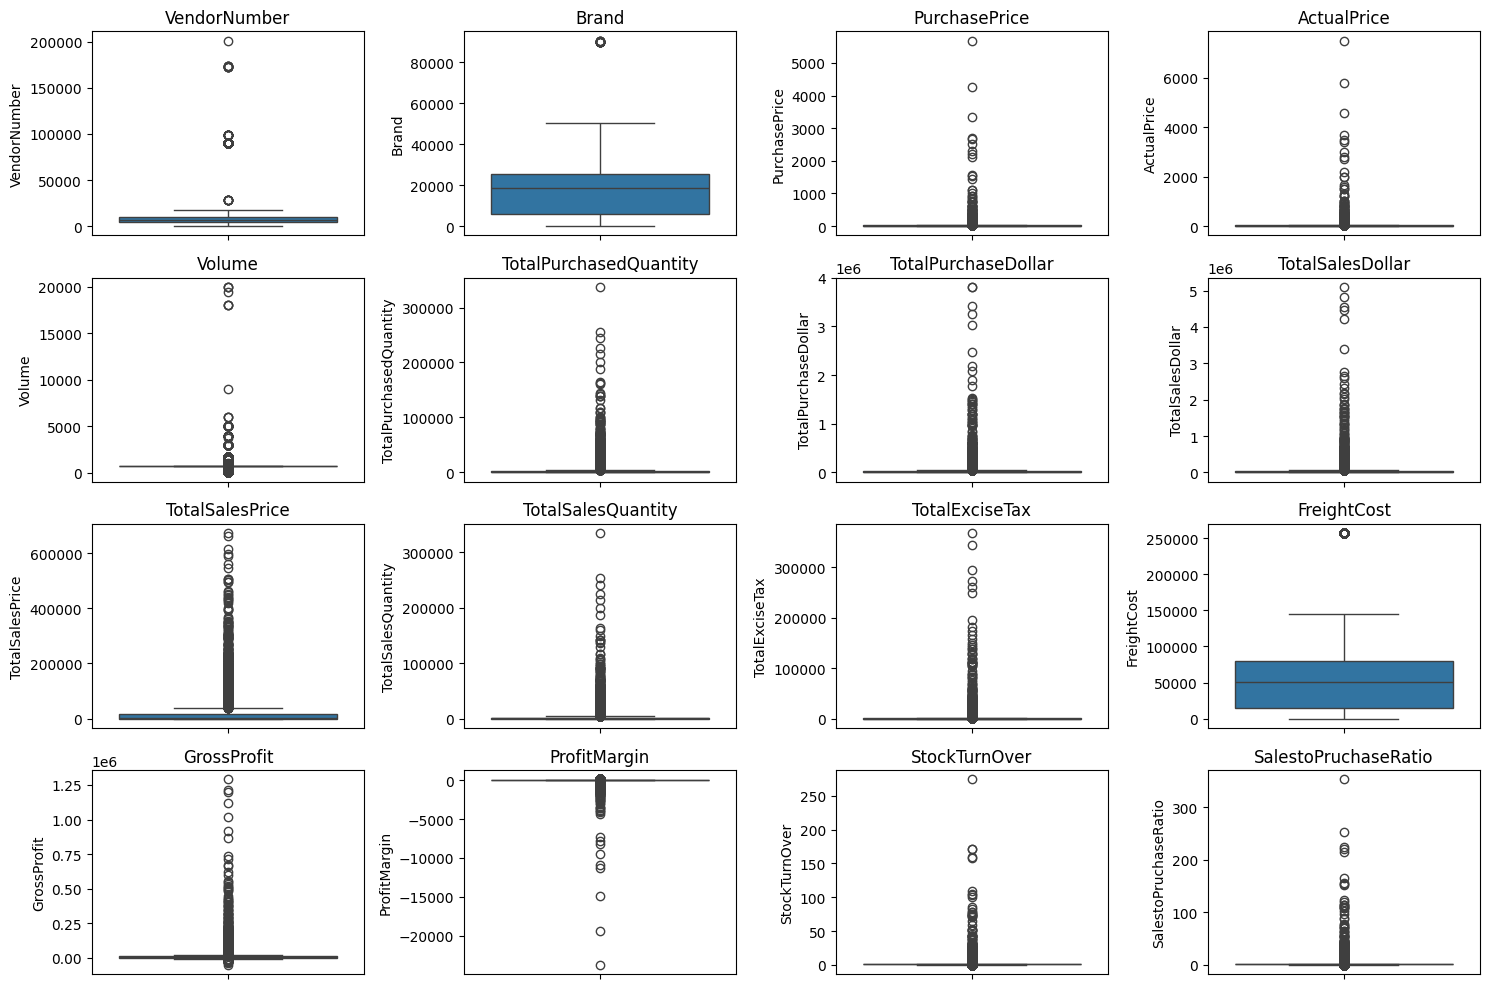

In [9]:

plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

# Summary Statistics Insight

Negative & Zero Values:

. Gross Profit: Minimum value is -52,002.78, indicating losses. Some products or transactions may be selling at a loss due to high costs or selling at discounts
lower than the purchase price . \
. Profit Margin: Has a minimum of -oo, which suggests cases where revenue is zero or even lower than costs.\
. Total Sales Quantity & Sales Dollars: Minimum values are 0, meaning some products were purchased but never sold. These could be slow-moving or obsolete
stock.

Outliers Indicated by High Standard Deviations:

. Purchase & Actual Prices: The max values (5,681.81 & 7,499.99) are significantly higher than the mean (24.39 & 35.64), indicating potential premium products. \
· Freight Cost: Huge variation, from 0.09 to 257,032.07, suggests logistics inefficiencies or bulk shipments.\
. Stock Turnover: Ranges from 0 to 274.5, implying some products sell extremely fast while others remain in stock indefinitely. Value more than 1 indicates that sold quantity for that product is higher than purchased quantity due to either sales are being fulfilled from older stock.

In [10]:
#  filtering the data by removing inconsistencies 

query = """
    SELECT * FROM new_vendor_sales_summary 
    WHERE GrossProfit > 0 AND ProfitMargin > 0
    AND TotalSalesQuantity > 0
"""
df = pd.read_sql_query(query, conn)
df

,VendorName,VendorNumber,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchasedQuantity,TotalPurchaseDollar,TotalSalesDollar,TotalSalesPrice,TotalSalesQuantity,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnOver,SalestoPruchaseRatio
0,BROWN-FORMAN CORP,1128,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,5101919.51,672819.31,142049.0,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,MARTIGNETTI COMPANIES,4425,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,4819073.49,561512.37,160247.0,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,PERNOD RICARD USA,17035,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,4538120.60,461140.15,187140.0,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,DIAGEO NORTH AMERICA INC,3960,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,4475972.88,420050.01,200412.0,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,DIAGEO NORTH AMERICA INC,3960,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,4223107.62,545778.28,135838.0,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8559,WINE GROUP INC,9815,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,15.95,10.96,5.0,0.55,27100.41,13.31,83.448276,2.500000,6.041667
8560,SAZERAC CO INC,8004,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,65.66,1.47,134.0,7.04,50293.62,63.32,96.436186,22.333333,28.059829
8561,HEAVEN HILL DISTILLERIES,3924,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,1.98,0.99,2.0,0.10,14069.87,0.50,25.252525,1.000000,1.337838
8562,DIAGEO NORTH AMERICA INC,3960,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,143.28,77.61,72.0,15.12,257032.07,141.81,98.974037,72.000000,97.469388


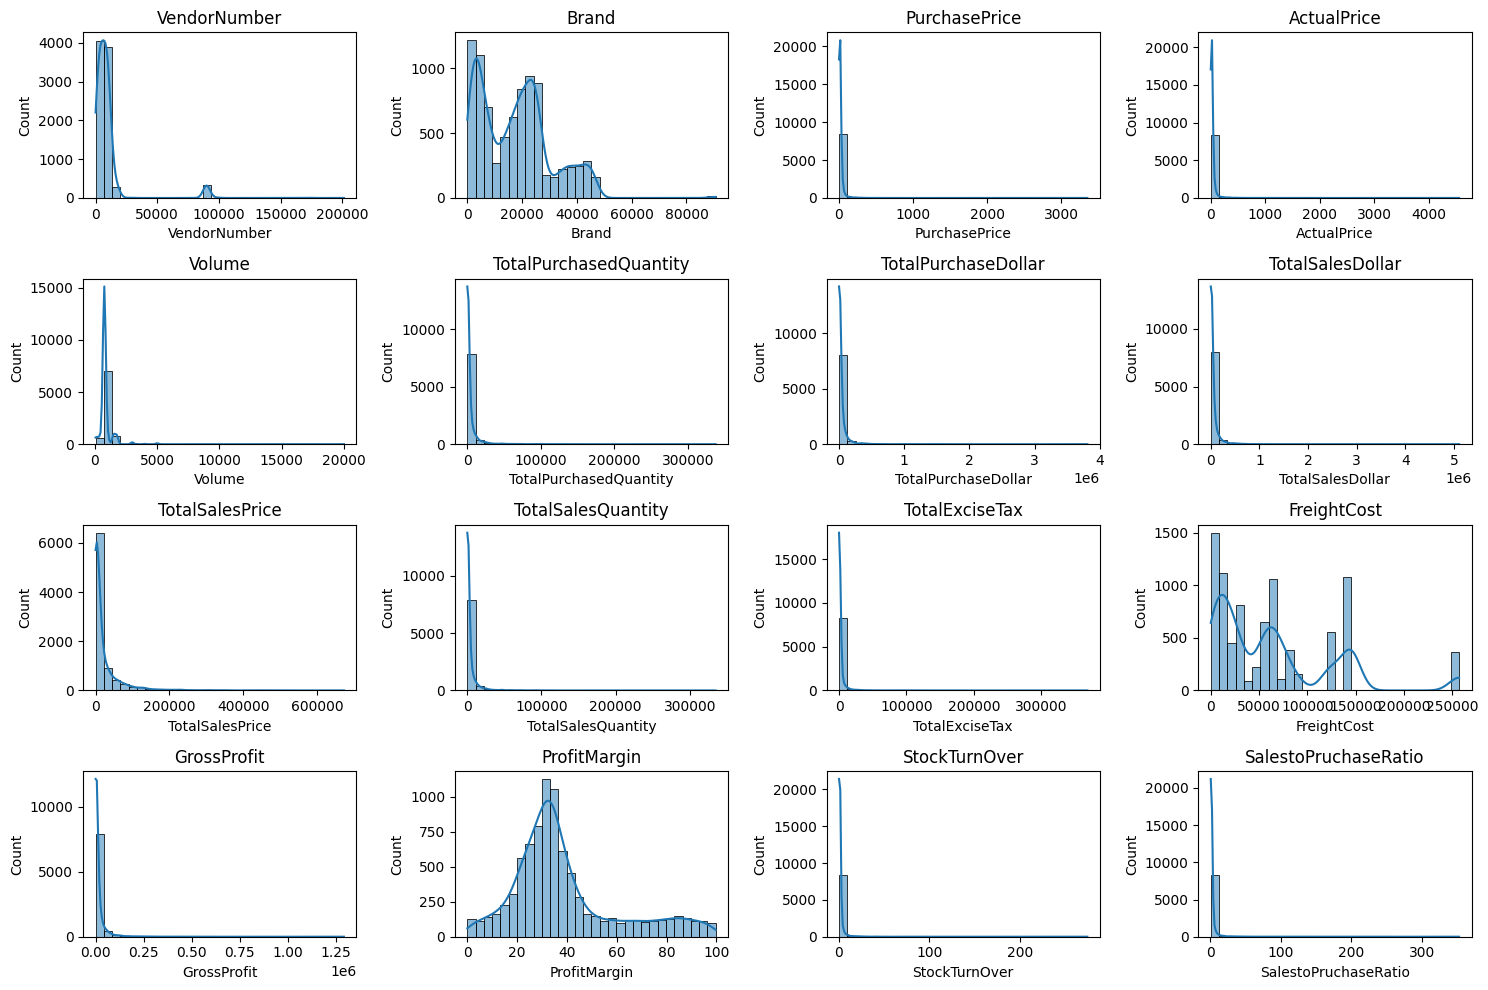

In [11]:
#  distribution plots for Numerical Colums

from re import L


numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

In [12]:
df.columns

Index(['VendorName', 'VendorNumber', 'Brand', 'Description', 'PurchasePrice',
       'ActualPrice', 'Volume', 'TotalPurchasedQuantity',
       'TotalPurchaseDollar', 'TotalSalesDollar', 'TotalSalesPrice',
       'TotalSalesQuantity', 'TotalExciseTax', 'FreightCost', 'GrossProfit',
       'ProfitMargin', 'StockTurnOver', 'SalestoPruchaseRatio'],
      dtype='str')

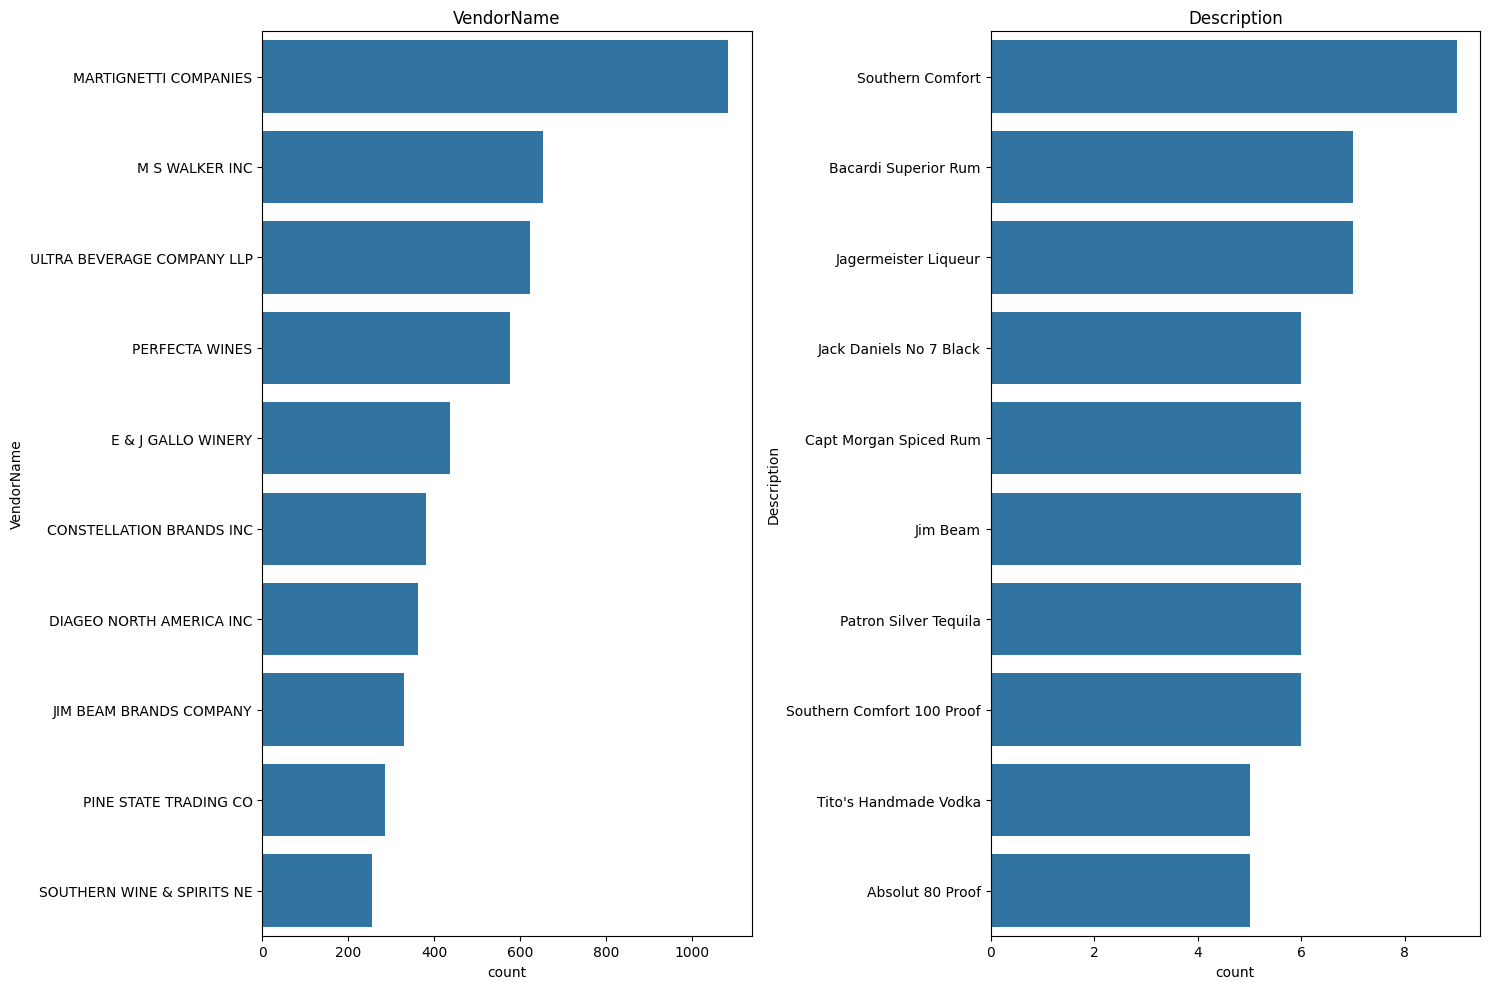

In [13]:
categorical_cols = ['VendorName', 'Description']   

# VendorName is Company Name
# Description is Product

plt.figure(figsize=(15,10))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 2, i+1)
    sns.countplot(y=df[col], order = df[col].value_counts().index[:10])    # Top 10 categories
    plt.title(col)
plt.tight_layout()
plt.show()

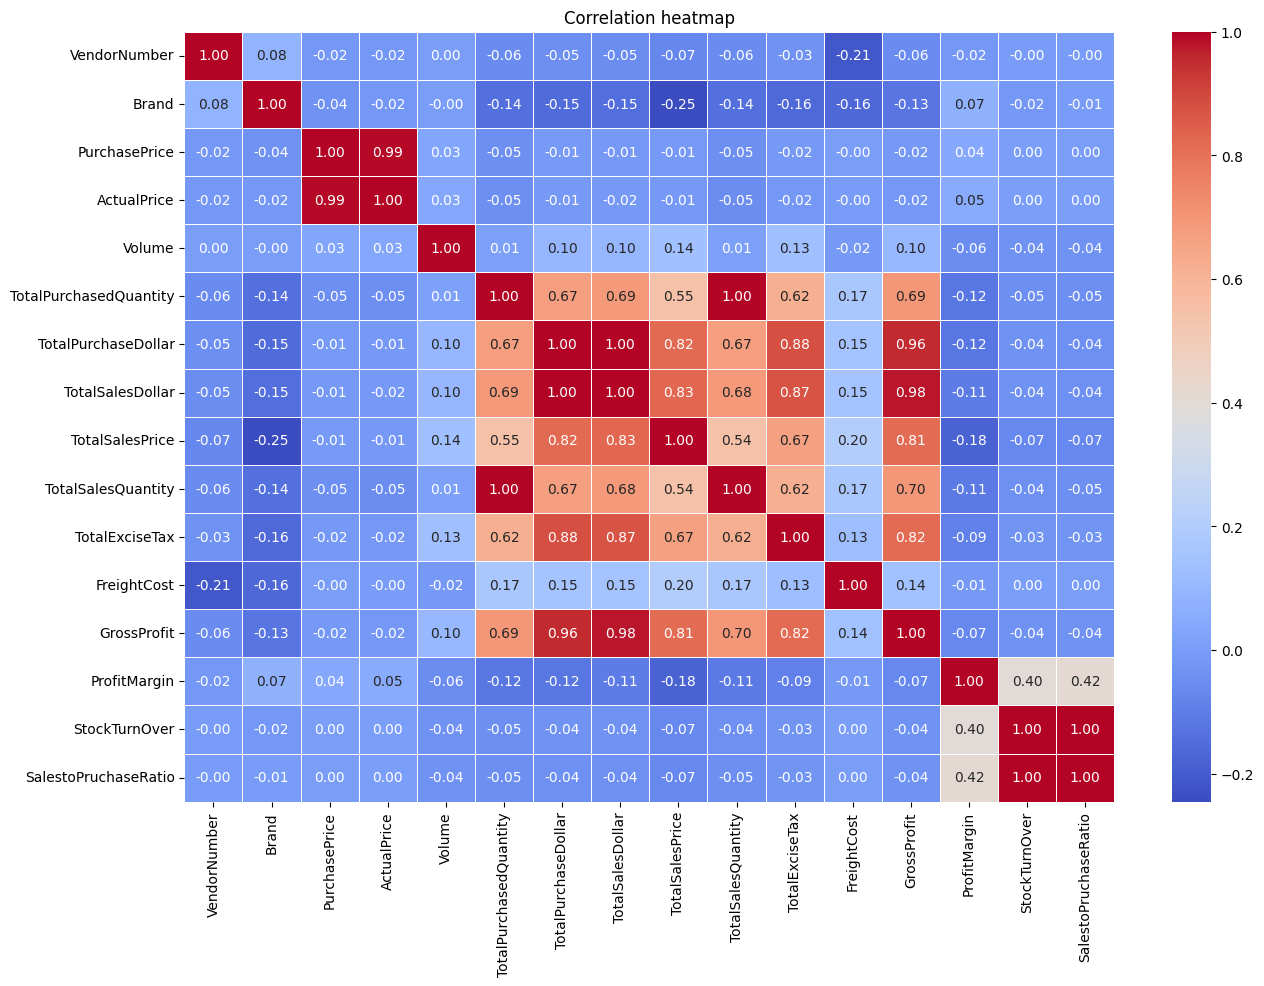

In [14]:
# Now we are checking the relationship between variables
# We are plotting a heatmap to analyze the correlation between them

plt.figure(figsize=(15,10))
correlation_matrix  = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation heatmap")
plt.show()

Correlation Insights

· PurchasePrice has weak correlations with TotalSalesDollars (-0.012) and GrossProfit (-0.016), suggesting that price variations do not significantly impact sales revenue or profit. \
· Strong correlation between total purchase quantity and total sales quantity (0.999), confirming efficient inventory turnover. \
· Negative correlation between profit margin & total sales price (-0.179) suggests that as sales price increases, margins decrease, possibly due to competitive pricing pressures. \
· StockTurnover has weak negative correlations with both GrossProfit (-0.038) and ProfitMargin (-0.055), indicating that faster turnover does not necessarily result in higher profitability.

# Data Analysis

Identify Brands that needs Promotional or Pricing Adjustments which exhibit lower sales performance but higher profit margins.

In [15]:
df.columns

Index(['VendorName', 'VendorNumber', 'Brand', 'Description', 'PurchasePrice',
       'ActualPrice', 'Volume', 'TotalPurchasedQuantity',
       'TotalPurchaseDollar', 'TotalSalesDollar', 'TotalSalesPrice',
       'TotalSalesQuantity', 'TotalExciseTax', 'FreightCost', 'GrossProfit',
       'ProfitMargin', 'StockTurnOver', 'SalestoPruchaseRatio'],
      dtype='str')

In [16]:
brand_performance_data = df.groupby(['VendorName', 'Description']).aggregate({
    'TotalSalesPrice': 'sum',
    'TotalSalesQuantity': 'sum',
    'TotalSalesDollar': 'sum',
    'ProfitMargin': 'mean'
}).reset_index()

brand_performance_data

,VendorName,Description,TotalSalesPrice,TotalSalesQuantity,TotalSalesDollar,ProfitMargin
0,ADAMBA IMPORTS INTL INC,Bak's Krupnik Honey Liqueur,494.67,47.0,704.53,36.672675
1,ALISA CARR BEVERAGES,Ch Cantenac Brown Margaux 11,359.94,30.0,1799.70,82.103684
2,ALISA CARR BEVERAGES,Ch Giscours Margaux 12,5269.15,165.0,10228.35,83.254777
3,ALISA CARR BEVERAGES,Ch Lafite Rothschild 12,4549.93,15.0,9749.85,72.413729
4,ALISA CARR BEVERAGES,Ch Le Petite Mouton 12 Pauil,2564.81,26.0,3509.74,84.193701
...,...,...,...,...,...,...
7719,ZORVINO VINEYARDS,Zorvino Fragole Z Strawberry,17963.16,1821.0,25475.79,34.133819
7720,ZORVINO VINEYARDS,Zorvino Vyds Mango Magnifico,13027.07,1299.0,16224.51,22.217682
7721,ZORVINO VINEYARDS,Zorvino Vyds Peachez,12167.82,1551.0,15494.49,24.035189
7722,ZORVINO VINEYARDS,Zorvino Vyds Pearz,15734.25,2065.0,20629.35,31.254499


In [17]:
low_sales_threshold =  brand_performance_data['TotalSalesDollar'].quantile(0.15)
high_margin_threshold =  brand_performance_data['ProfitMargin'].quantile(0.85)


print(f"low_sales_threshold: {low_sales_threshold}")
print(f"high_margin_threshold: {high_margin_threshold}")

low_sales_threshold: 560.413
high_margin_threshold: 65.00495955109605


In [18]:

'''
condotion for target brands
high_margin_threshold: >  65
low_sales_threshold < 560.413

'''

#  Filter brands with low sales but high profit margins

target_brands = brand_performance_data[
    (brand_performance_data['TotalSalesDollar'] <= low_sales_threshold) & 
    (brand_performance_data['ProfitMargin'] >= high_margin_threshold)
]
# these brands has high profit margin but low sale
target_brands

,VendorName,Description,TotalSalesPrice,TotalSalesQuantity,TotalSalesDollar,ProfitMargin
49,BACARDI USA INC,Bacardi Limon Traveler,309.69,41.0,409.59,96.440343
54,BACARDI USA INC,Bacardi Oakheart Spiced Trav,369.63,40.0,399.60,98.133133
103,BACARDI USA INC,Leblon Cedilla Acai Liqueur,89.97,3.0,89.97,73.335556
150,BANFI PRODUCTS CORP,C Y Toro Carmenere Terrunyo,131.94,8.0,175.92,91.774670
213,BANFI PRODUCTS CORP,Riunite Sweet White,131.78,27.0,161.73,97.464911
...,...,...,...,...,...,...
7453,VINILANDIA USA,Tiki Sound Svgn Bl,146.86,29.0,326.71,67.751217
7466,VRANKEN AMERICA,Ch La Gordonne Chapelle Rose,167.94,6.0,167.94,88.740026
7600,WINE GROUP INC,Concannon Glen Ellen Wh Zin,10.96,5.0,15.95,83.448276
7646,WINE GROUP INC,Flipflop Spiced Rum,200.78,43.0,389.57,70.921786


In [19]:
brand_performance_data = brand_performance_data[brand_performance_data['TotalSalesDollar'] < 10000]

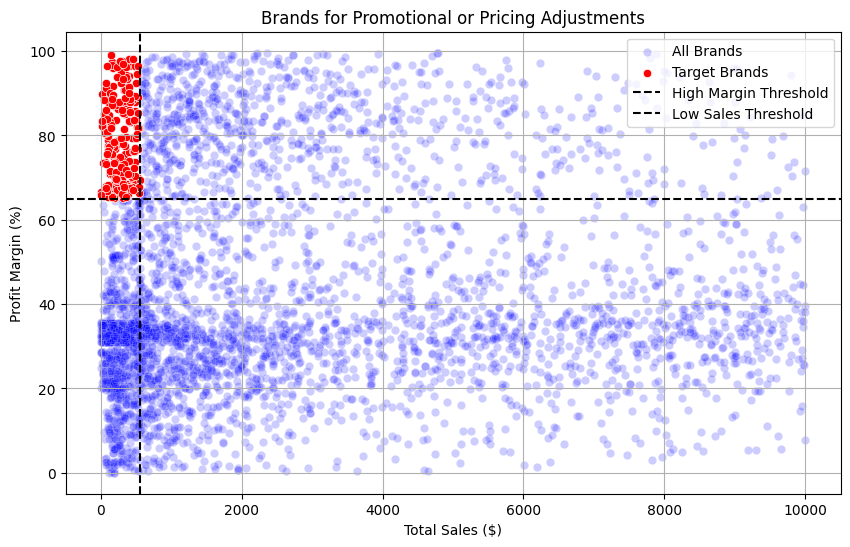

In [20]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=brand_performance_data, x='TotalSalesDollar', y='ProfitMargin', color="blue", label="All Brands", alpha = 0.2)
sns.scatterplot(data=target_brands, x='TotalSalesDollar', y='ProfitMargin', color="red", label="Target Brands")

plt.axhline(high_margin_threshold, linestyle='--', color='black', label="High Margin Threshold")
plt.axvline(low_sales_threshold, linestyle='--', color='black', label="Low Sales Threshold")

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotional or Pricing Adjustments")
plt.legend()
plt.grid(True)
plt.show()

Which vendors and brands demonstrate the highest sales performance?

In [21]:
df.columns

Index(['VendorName', 'VendorNumber', 'Brand', 'Description', 'PurchasePrice',
       'ActualPrice', 'Volume', 'TotalPurchasedQuantity',
       'TotalPurchaseDollar', 'TotalSalesDollar', 'TotalSalesPrice',
       'TotalSalesQuantity', 'TotalExciseTax', 'FreightCost', 'GrossProfit',
       'ProfitMargin', 'StockTurnOver', 'SalestoPruchaseRatio'],
      dtype='str')

In [23]:
top_vendors = df.groupby("VendorName")["TotalSalesDollar"].sum().nlargest(10)
top_brands = df.groupby("Description")["TotalSalesDollar"].sum().nlargest(10)
top_vendors

VendorName
DIAGEO NORTH AMERICA INC      67990099.42
MARTIGNETTI COMPANIES         39330359.36
PERNOD RICARD USA             32063196.19
JIM BEAM BRANDS COMPANY       31423020.46
BACARDI USA INC               24854817.14
CONSTELLATION BRANDS INC      24218745.65
E & J GALLO WINERY            18399899.46
BROWN-FORMAN CORP             18247230.65
ULTRA BEVERAGE COMPANY LLP    16502544.31
M S WALKER INC                14706458.51
Name: TotalSalesDollar, dtype: float64

In [24]:
top_brands

Description
Jack Daniels No 7 Black    7964746.76
Tito's Handmade Vodka      7399657.58
Grey Goose Vodka           7209608.06
Capt Morgan Spiced Rum     6356320.62
Absolut 80 Proof           6244752.03
Jameson Irish Whiskey      5715759.69
Ketel One Vodka            5070083.56
Baileys Irish Cream        4150122.07
Kahlua                     3604858.66
Tanqueray                  3456697.90
Name: TotalSalesDollar, dtype: float64

In [30]:
vendor_perf = df.groupby(['VendorName']).agg({
    'TotalSalesDollar': 'sum',
    'TotalSalesQuantity': 'sum'
}).reset_index()

top_vendors = vendor_perf.sort_values(by='TotalSalesDollar', ascending=False)
top_vendors.head(10)

,VendorName,TotalSalesDollar,TotalSalesQuantity
25,DIAGEO NORTH AMERICA INC,67990099.42,5383490.0
57,MARTIGNETTI COMPANIES,39330359.36,2488162.0
68,PERNOD RICARD USA,32063196.19,1605783.0
46,JIM BEAM BRANDS COMPANY,31423020.46,2527234.0
6,BACARDI USA INC,24854817.14,1429076.0
20,CONSTELLATION BRANDS INC,24218745.65,2283566.0
30,E & J GALLO WINERY,18399899.46,1781398.0
11,BROWN-FORMAN CORP,18247230.65,977635.0
106,ULTRA BEVERAGE COMPANY LLP,16502544.31,977939.0
53,M S WALKER INC,14706458.51,1294175.0


In [ ]:
brands_perf = df.groupby(['Description']).agg({
    'TotalSalesDollar': 'sum',
    'TotalSalesQuantity': 'sum'
}).reset_index()

top_brands = brands_perf.sort_values(by='TotalSalesDollar', ascending=False)
top_brands.head(10)

,Description,TotalSalesDollar,TotalSalesQuantity
3771,Jack Daniels No 7 Black,7964746.76,334824.0
7114,Tito's Handmade Vodka,7399657.58,358288.0
3402,Grey Goose Vodka,7209608.06,274794.0
1272,Capt Morgan Spiced Rum,6356320.62,385838.0
86,Absolut 80 Proof,6244752.03,341297.0
3850,Jameson Irish Whiskey,5715759.69,235981.0
4101,Ketel One Vodka,5070083.56,189684.0
478,Baileys Irish Cream,4150122.07,237743.0
4019,Kahlua,3604858.66,212434.0
6846,Tanqueray,3456697.90,152510.0


In [25]:
def format_dollars(value):
    if value >= 1_000_000:
        return f"{value / 1_000_000:.2f}M"
    elif value >= 1_000:
        return f"{value / 1_000:.2f}K"
    elif value >= 1_00:
        return f"{value / 1_00:.2f}"
    else:
        return f"{value:.2f}"


In [29]:
top_vendors.apply(lambda x:format_dollars(x))

VendorName
DIAGEO NORTH AMERICA INC      67.99M
MARTIGNETTI COMPANIES         39.33M
PERNOD RICARD USA             32.06M
JIM BEAM BRANDS COMPANY       31.42M
BACARDI USA INC               24.85M
CONSTELLATION BRANDS INC      24.22M
E & J GALLO WINERY            18.40M
BROWN-FORMAN CORP             18.25M
ULTRA BEVERAGE COMPANY LLP    16.50M
M S WALKER INC                14.71M
Name: TotalSalesDollar, dtype: str

In [ ]:
top_vendors

,VendorName,TotalSalesDollar,TotalSalesQuantity
25,DIAGEO NORTH AMERICA INC,67990099.42,5383490.0
57,MARTIGNETTI COMPANIES,39330359.36,2488162.0
68,PERNOD RICARD USA,32063196.19,1605783.0
46,JIM BEAM BRANDS COMPANY,31423020.46,2527234.0
6,BACARDI USA INC,24854817.14,1429076.0
...,...,...,...
44,"IRA GOLDMAN AND WILLIAMS, LLP",665.82,18.0
85,SILVER MOUNTAIN CIDERS,342.51,49.0
33,FANTASY FINE WINES CORP,327.59,41.0
16,CAPSTONE INTERNATIONAL,246.87,13.0


In [ ]:
plt.figure(figsize=(15, 5))

# Convert to proper 1D Series
top_vendors_series = top_vendors.iloc[:, 0] if hasattr(top_vendors, "iloc") else top_vendors
top_brands_series = top_brands.iloc[:, 0] if hasattr(top_brands, "iloc") else top_brands

# Plot for Top Vendors
plt.subplot(1, 2, 1)
ax1 = sns.barplot(
    y=top_vendors_series.index,
    x=top_vendors_series.values,
    palette="Blues_r"
)
plt.title("Top 10 Vendors by Sales")

for bar in ax1.patches:
    ax1.text(
        bar.get_width() + (bar.get_width() * 0.02),
        bar.get_y() + bar.get_height() / 2,
        format_dollars(bar.get_width()),
        ha='left', va='center', fontsize=10, color='black'
    )

# Plot for Top Brands
plt.subplot(1, 2, 2)
ax2 = sns.barplot(
    y=top_brands_series.index.astype(str),
    x=top_brands_series.values,
    palette="Reds_r"
)
plt.title("Top 10 Brands by Sales")

for bar in ax2.patches:
    ax2.text(
        bar.get_width() + (bar.get_width() * 0.02),
        bar.get_y() + bar.get_height() / 2,
        format_dollars(bar.get_width()),
        ha='left', va='center', fontsize=10, color='black'
    )

plt.tight_layout()
plt.show()

C:\Users\Shubhankar\AppData\Local\Temp\ipykernel_19036\2101913175.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(
C:\Users\Shubhankar\AppData\Local\Temp\ipykernel_19036\2101913175.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(


KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x000001B788F078A0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 